<a href="https://colab.research.google.com/github/ADRIAN-GP84/Alura-Store/blob/main/Sentiment_analysis_mvp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sentimiento – MVP Hackathon

## Objetivo
Construir un modelo de Machine Learning capaz de clasificar textos
(comentarios, reseñas o tweets) en **Positivo, Neutro o Negativo**.

El modelo será expuesto a través de una API para que aplicaciones
puedan consumir la predicción automáticamente.

## Enfoque
- TF-IDF para vectorizar texto
- Logistic Regression como modelo supervisado
- Evaluación con métricas estándar
- Serialización para uso en producción


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("test.csv", encoding='latin1')
df.head()

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

import joblib

In [ ]:
df.columns


Index(['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User',
       'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'],
      dtype='object')

In [ ]:
df = df[["text", "sentiment"]]
df.head()

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [ ]:
df["sentiment"] = df["sentiment"].str.capitalize()

df["sentiment"].value_counts()

,count
sentiment,
Neutral,1430
Positive,1103
Negative,1001


#Mapeo de etiquetas


In [ ]:
df["sentiment"] = df["sentiment"].map({
    "Positive": "Positivo",
    "Neutral": "Neutro",
    "Negative": "Negativo"
})

df.head()

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,Neutro
1,Shanghai is also really exciting (precisely -...,Positivo
2,"Recession hit Veronique Branquinho, she has to...",Negativo
3,happy bday!,Positivo
4,http://twitpic.com/4w75p - I like it!!,Positivo


In [ ]:
df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"].str.len() > 5]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3533 entries, 0 to 3533
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       3533 non-null   object
 1   sentiment  3533 non-null   object
dtypes: object(2)
memory usage: 82.8+ KB


In [ ]:
df.shape

(3533, 2)

In [ ]:
df["sentiment"].value_counts()

df["sentiment"].value_counts(normalize=True)

,proportion
sentiment,
Neutro,0.404472
Positivo,0.312199
Negativo,0.283329


In [ ]:
df.isnull().sum()

,0
text,0
sentiment,0


textos cortos → tweets

TF-IDF es adecuado

In [ ]:
df["text_length"] = df["text"].str.len()
df["text_length"].describe()

,text_length
count,3533.000000
mean,67.795641
std,35.579535
min,6.000000
25%,38.000000
50%,63.000000
75%,97.000000
max,148.000000


Comparar longitud por sentimiento (EDA útil)

“Los comentarios negativos tienden a ser ligeramente más largos.”

In [ ]:
df.groupby("sentiment")["text_length"].mean()


,text_length
sentiment,
Negativo,69.639361
Neutro,65.776067
Positivo,68.738894


#Ejemplos reales por clase

In [ ]:
df[df["sentiment"] == "Positivo"]["text"].head(3)


,text
1,Shanghai is also really exciting (precisely -...
3,happy bday!
4,http://twitpic.com/4w75p - I like it!!


In [ ]:
df[df["sentiment"] == "Negativo"]["text"].head(3)


,text
2,"Recession hit Veronique Branquinho, she has to..."
6,I THINK EVERYONE HATES ME ON HERE lol
7,"soooooo wish i could, but im in school and my..."


In [ ]:
df[df["sentiment"] == "Neutro"]["text"].head(3)


,text
0,Last session of the day http://twitpic.com/67ezh
8,and within a short time of the last clue all ...
9,What did you get? My day is alright.. haven`...


#Visualización simple

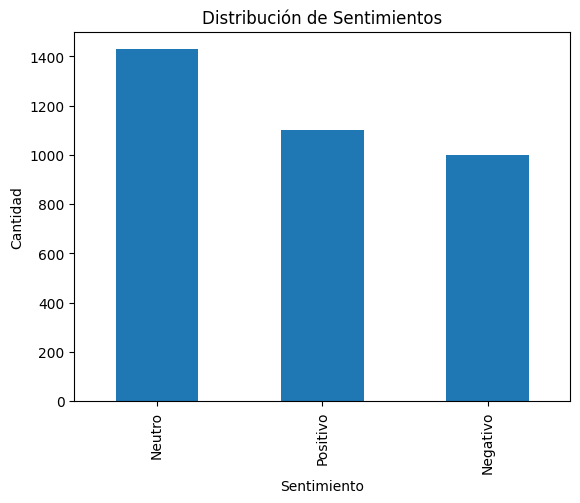

In [ ]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribución de Sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()

#Separación de datos

In [ ]:
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Pipeline TF-IDF + Modelo

In [ ]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words=None,
        max_features=5000
    )),
    ("model", LogisticRegression(max_iter=1000))
])


In [ ]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('model', LogisticRegression(max_iter=1000))])

##Evaluación

# Sección nueva

In [ ]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6605374823196606
              precision    recall  f1-score   support

    Negativo       0.69      0.55      0.61       211
      Neutro       0.57      0.75      0.65       278
    Positivo       0.81      0.65      0.72       218

    accuracy                           0.66       707
   macro avg       0.69      0.65      0.66       707
weighted avg       0.68      0.66      0.66       707



###Prueba manual

In [ ]:
pipeline.predict(["El soporte técnico fue horrible"])

array(['Negativo'], dtype=object)

In [ ]:
pipeline.predict_proba(["El soporte técnico fue horrible"])


array([[0.4695461 , 0.32973751, 0.20071639]])

##Serialización del modelo

In [ ]:
joblib.dump(pipeline, "sentiment_model.pkl")

['sentiment_model.pkl']

El modelo se guarda para ser utilizado por la API en producción.
